In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

In [ ]:
sns.set_theme(style="whitegrid", palette="Blues_d")

COLORS = {
    "ml":       "#1a56a0",
    "nlp":      "#2e86c1",
    "vision":   "#1abc9c",
    "speech":   "#f39c12",
    "planning": "#8e44ad",
    "evo":      "#c0392b",
    "kr":       "#27ae60",
    "hardware": "#e67e22",
}

SUBFIELDS = ["ml", "nlp", "vision", "speech", "planning", "evo", "kr", "hardware"]

SUBFIELD_LABELS = {
    "ml":       "Machine Learning",
    "nlp":      "Natural Language Processing",
    "vision":   "Computer Vision",
    "speech":   "Speech Recognition",
    "planning": "Planning & Reasoning",
    "evo":      "Evolutionary Computation",
    "kr":       "Knowledge Representation",
    "hardware": "AI Hardware",
}

In [ ]:
OUTPUT_DIR = "powerbi_tables"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs("charts", exist_ok=True)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
CSV_PATH    = "/content/drive/MyDrive/ai_model_predictions.csv"
OUTPUT_PATH = "/content/processed_ai_model_predictions.csv"

# Data Processing

In [ ]:
CHUNK_SIZE   = 200_000
first_chunk  = True
total_rows   = 0
total_ai_86  = 0
subfield_counts = Counter()

for i, chunk in enumerate(pd.read_csv(CSV_PATH, chunksize=CHUNK_SIZE, low_memory=False)):
    print(f"Pass 1 — chunk {i+1}")

    # ── Date parsing ─────────────────────────────────────────────────────────
    chunk["pub_dt"] = pd.to_datetime(chunk["pub_dt"], errors="coerce")
    chunk["year"]   = chunk["pub_dt"].dt.year
    chunk["month"]  = chunk["pub_dt"].dt.month

    chunk = chunk.dropna(subset=["year"])
    chunk["year"] = chunk["year"].astype(int)
    chunk = chunk[(chunk["year"] >= 1976) & (chunk["year"] <= 2024)]

    # ── Flag cleaning ────────────────────────────────────────────────────────
    flag_cols = [c for c in chunk.columns if c.startswith(("predict", "flag", "ai_score"))]
    chunk[flag_cols] = chunk[flag_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

    # ── Dominant subfield ────────────────────────────────────────────────────
    score_cols = [f"ai_score_{sf}" for sf in SUBFIELDS if f"ai_score_{sf}" in chunk.columns]

    if score_cols:
        chunk["dominant_subfield"] = chunk[score_cols].idxmax(axis=1)
        chunk["dominant_subfield"] = chunk["dominant_subfield"].str.replace("ai_score_", "", regex=False)
        chunk.loc[chunk["predict86_any_ai"] == 0, "dominant_subfield"] = "non_ai"
    else:
        chunk["dominant_subfield"] = "unknown"

    # ── AI binary flags ──────────────────────────────────────────────────────
    chunk["is_ai_86"] = chunk["predict86_any_ai"].astype(int)
    chunk["is_ai_50"] = chunk["predict50_any_ai"].astype(int)
    chunk["is_ai_93"] = chunk["predict93_any_ai"].astype(int)

    # ── Accumulate global stats ───────────────────────────────────────────────
    total_rows  += len(chunk)
    total_ai_86 += chunk["is_ai_86"].sum()
    subfield_counts.update(chunk["dominant_subfield"].value_counts().to_dict())

    # ── Write processed chunk ─────────────────────────────────────────────────
    chunk.to_csv(
        OUTPUT_PATH,
        mode="w" if first_chunk else "a",
        header=first_chunk,
        index=False
    )
    first_chunk = False

    print(f"  Rows so far: {total_rows:,}")

print(f"\nPass 1 complete.")
print(f"Total patents:            {total_rows:,}")
print(f"AI patents (86%):         {total_ai_86:,}")
print(f"AI share:                 {total_ai_86/total_rows*100:.2f}%")
print("\nDominant subfield distribution:")
for k, v in subfield_counts.most_common():
    print(f"  {k}: {v:,}")

Pass 1 — chunk 1
  Rows so far: 200,000
Pass 1 — chunk 2
  Rows so far: 400,000
Pass 1 — chunk 3
  Rows so far: 600,000
Pass 1 — chunk 4
  Rows so far: 800,000
Pass 1 — chunk 5
  Rows so far: 1,000,000
Pass 1 — chunk 6
  Rows so far: 1,200,000
Pass 1 — chunk 7
  Rows so far: 1,400,000
Pass 1 — chunk 8
  Rows so far: 1,600,000
Pass 1 — chunk 9
  Rows so far: 1,800,000
Pass 1 — chunk 10
  Rows so far: 2,000,000
Pass 1 — chunk 11
  Rows so far: 2,200,000
Pass 1 — chunk 12
  Rows so far: 2,400,000
Pass 1 — chunk 13
  Rows so far: 2,600,000
Pass 1 — chunk 14
  Rows so far: 2,800,000
Pass 1 — chunk 15
  Rows so far: 3,000,000
Pass 1 — chunk 16
  Rows so far: 3,200,000
Pass 1 — chunk 17
  Rows so far: 3,400,000
Pass 1 — chunk 18
  Rows so far: 3,600,000
Pass 1 — chunk 19
  Rows so far: 3,800,000
Pass 1 — chunk 20
  Rows so far: 4,000,000
Pass 1 — chunk 21
  Rows so far: 4,200,000
Pass 1 — chunk 22
  Rows so far: 4,400,000
Pass 1 — chunk 23
  Rows so far: 4,600,000
Pass 1 — chunk 24
  Rows so 

#Aggregated Tables

In [ ]:
CHUNK_SIZE = 100_000

year_stats    = defaultdict(lambda: {"total": 0, "ai50": 0, "ai86": 0, "ai93": 0})
subfield_year = defaultdict(lambda: {"p50": 0, "p86": 0, "p93": 0, "score_sum": 0, "count": 0})
dominant_year = defaultdict(int)
decade_stats  = defaultdict(lambda: {"total": 0, "ai": 0})

for i, chunk in enumerate(pd.read_csv(OUTPUT_PATH, chunksize=CHUNK_SIZE)):
    print(f"Pass 2 — chunk {i+1}")

    chunk["is_ai_50"] = chunk["predict50_any_ai"].astype(int)
    chunk["is_ai_86"] = chunk["predict86_any_ai"].astype(int)
    chunk["is_ai_93"] = chunk["predict93_any_ai"].astype(int)

    # Table 1: yearly totals
    for year, grp in chunk.groupby("year"):
        year_stats[year]["total"] += len(grp)
        year_stats[year]["ai50"]  += grp["is_ai_50"].sum()
        year_stats[year]["ai86"]  += grp["is_ai_86"].sum()
        year_stats[year]["ai93"]  += grp["is_ai_93"].sum()

    # Table 2 & 3: subfield by year
    for year, grp in chunk.groupby("year"):
        for sf in SUBFIELDS:
            col50  = f"predict50_{sf}"
            col86  = f"predict86_{sf}"
            col93  = f"predict93_{sf}"
            score  = f"ai_score_{sf}"

            if col86 not in grp.columns:
                continue

            key = (year, sf)
            subfield_year[key]["p86"]       += grp[col86].sum()
            subfield_year[key]["p50"]       += grp[col50].sum() if col50 in grp.columns else 0
            subfield_year[key]["p93"]       += grp[col93].sum() if col93 in grp.columns else 0
            subfield_year[key]["score_sum"] += grp[score].sum() if score in grp.columns else 0
            subfield_year[key]["count"]     += len(grp)

    # Table 6: dominant subfield by yer
    dom = chunk[chunk["dominant_subfield"].isin(SUBFIELDS)]
    for (year, sf), grp in dom.groupby(["year", "dominant_subfield"]):
        dominant_year[(year, sf)] += len(grp)

    #Table 5: decade summary
    chunk["decade"] = (chunk["year"] // 10) * 10
    for dec, grp in chunk.groupby("decade"):
        decade_stats[dec]["total"] += len(grp)
        decade_stats[dec]["ai"]    += grp["is_ai_86"].sum()

print("\nPass 2 complete. Building output tables...")


Pass 2 — chunk 1
Pass 2 — chunk 2
Pass 2 — chunk 3
Pass 2 — chunk 4
Pass 2 — chunk 5
Pass 2 — chunk 6
Pass 2 — chunk 7
Pass 2 — chunk 8
Pass 2 — chunk 9
Pass 2 — chunk 10
Pass 2 — chunk 11
Pass 2 — chunk 12
Pass 2 — chunk 13
Pass 2 — chunk 14
Pass 2 — chunk 15
Pass 2 — chunk 16
Pass 2 — chunk 17
Pass 2 — chunk 18
Pass 2 — chunk 19
Pass 2 — chunk 20
Pass 2 — chunk 21
Pass 2 — chunk 22
Pass 2 — chunk 23
Pass 2 — chunk 24
Pass 2 — chunk 25
Pass 2 — chunk 26
Pass 2 — chunk 27
Pass 2 — chunk 28
Pass 2 — chunk 29
Pass 2 — chunk 30
Pass 2 — chunk 31
Pass 2 — chunk 32
Pass 2 — chunk 33
Pass 2 — chunk 34
Pass 2 — chunk 35
Pass 2 — chunk 36
Pass 2 — chunk 37
Pass 2 — chunk 38
Pass 2 — chunk 39
Pass 2 — chunk 40
Pass 2 — chunk 41
Pass 2 — chunk 42
Pass 2 — chunk 43
Pass 2 — chunk 44
Pass 2 — chunk 45
Pass 2 — chunk 46
Pass 2 — chunk 47
Pass 2 — chunk 48
Pass 2 — chunk 49
Pass 2 — chunk 50
Pass 2 — chunk 51
Pass 2 — chunk 52
Pass 2 — chunk 53
Pass 2 — chunk 54
Pass 2 — chunk 55
Pass 2 — chunk 56
P

In [ ]:
# Table 1 — Yearly Totals
rows = []
for year, data in year_stats.items():
    rows.append({
        "year":           year,
        "total_patents":  data["total"],
        "ai_patents_50":  data["ai50"],
        "ai_patents_86":  data["ai86"],
        "ai_patents_93":  data["ai93"],
    })

yearly_total = pd.DataFrame(rows).sort_values("year")
yearly_total["ai_share_86"] = (yearly_total["ai_patents_86"] / yearly_total["total_patents"] * 100).round(2)
yearly_total["yoy_growth"]  = yearly_total["ai_patents_86"].pct_change() * 100
yearly_total.to_csv(f"{OUTPUT_DIR}/01_yearly_totals.csv", index=False)
print("  Saved: 01_yearly_totals.csv")

#Table 2 — Subfield by Year
rows = []
for (year, sf), data in subfield_year.items():
    rows.append({
        "year":          year,
        "subfield":      sf,
        "subfield_label":SUBFIELD_LABELS[sf],
        "patents_50":    data["p50"],
        "patents_86":    data["p86"],
        "patents_93":    data["p93"],
        "avg_score":     data["score_sum"] / data["count"] if data["count"] > 0 else 0,
    })

df_subfields = pd.DataFrame(rows)
df_subfields.to_csv(f"{OUTPUT_DIR}/02_subfield_by_year.csv", index=False)
print("  Saved: 02_subfield_by_year.csv")

# Table 3 — Subfield Summary
total_ai = sum(v["p86"] for v in subfield_year.values())
rows = []
for sf in SUBFIELDS:
    sf_data = {k: v for k, v in subfield_year.items() if k[1] == sf}
    total  = sum(v["p86"] for v in sf_data.values())
    recent = sum(v["p86"] for (yr, s), v in sf_data.items() if yr >= 2018)
    rows.append({
        "subfield":          sf,
        "subfield_label":    SUBFIELD_LABELS[sf],
        "total_patents_86":  total,
        "recent_patents_86": recent,
        "share_of_ai_pct":   round(total / total_ai * 100, 2) if total_ai > 0 else 0,
    })

# Explicitly sort descending so iloc[0] == top subfield in Key Stats
df_summary = pd.DataFrame(rows).sort_values("total_patents_86", ascending=False).reset_index(drop=True)
df_summary.to_csv(f"{OUTPUT_DIR}/03_subfield_summary.csv", index=False)
print("  Saved: 03_subfield_summary.csv")

# Table 4 — Confidence Tiers by Year
df_tiers = yearly_total[["year", "ai_patents_50", "ai_patents_86", "ai_patents_93"]].copy()
df_tiers.columns = ["year", "threshold_50", "threshold_86", "threshold_93"]
df_tiers.to_csv(f"{OUTPUT_DIR}/04_confidence_tiers_by_year.csv", index=False)
print("  Saved: 04_confidence_tiers_by_year.csv")

# Table 5 — Decade Summary
rows = []
for dec, data in decade_stats.items():
    rows.append({
        "decade":       f"{dec}s",
        "total_patents":data["total"],
        "ai_patents":   data["ai"],
        "ai_share_pct": round(data["ai"] / data["total"] * 100, 2),
    })

decade_summary = pd.DataFrame(rows).sort_values("decade")
decade_summary.to_csv(f"{OUTPUT_DIR}/05_decade_summary.csv", index=False)
print("  Saved: 05_decade_summary.csv")

#Table 6 — Dominant Subfield by Year
rows = []
for (year, sf), count in dominant_year.items():
    rows.append({
        "year":              year,
        "dominant_subfield": sf,
        "subfield_label":    SUBFIELD_LABELS[sf],
        "patents":           count,
    })

dominant_by_year = pd.DataFrame(rows)
dominant_by_year.to_csv(f"{OUTPUT_DIR}/06_dominant_subfield_by_year.csv", index=False)
print("  Saved: 06_dominant_subfield_by_year.csv")

  Saved: 01_yearly_totals.csv
  Saved: 02_subfield_by_year.csv
  Saved: 03_subfield_summary.csv
  Saved: 04_confidence_tiers_by_year.csv
  Saved: 05_decade_summary.csv
  Saved: 06_dominant_subfield_by_year.csv


# EDA Visualization

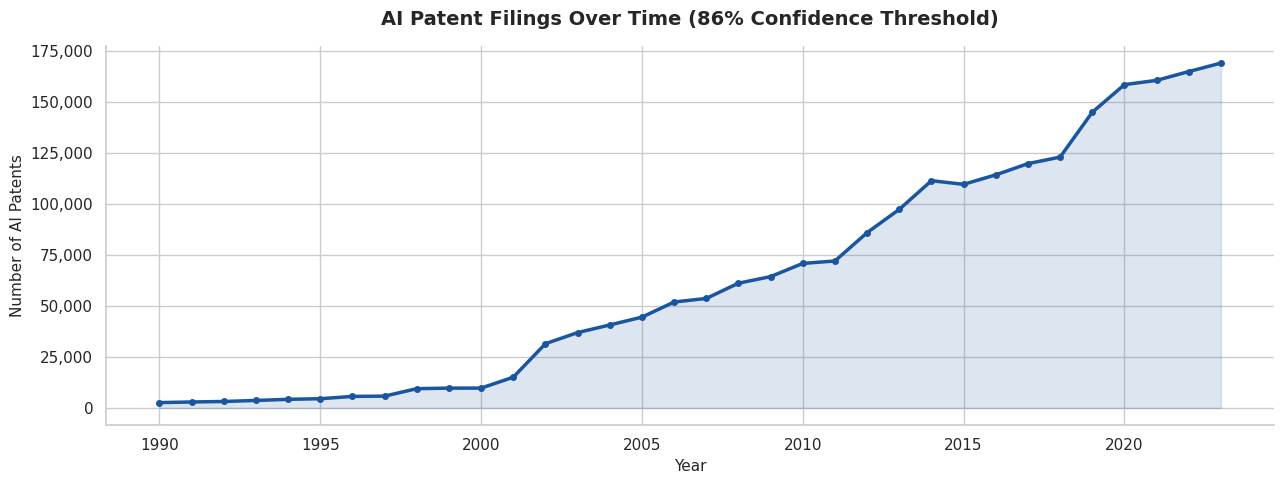

  Chart 1: AI patents over time


In [ ]:
recent = yearly_total[yearly_total["year"] >= 1990]

# Chart 1 — AI patents over time
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(recent["year"], recent["ai_patents_86"], alpha=0.15, color="#1a56a0")
ax.plot(recent["year"], recent["ai_patents_86"], color="#1a56a0", linewidth=2.5, marker="o", markersize=4)
ax.set_title("AI Patent Filings Over Time (86% Confidence Threshold)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of AI Patents", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/01_ai_patents_over_time.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 1: AI patents over time")

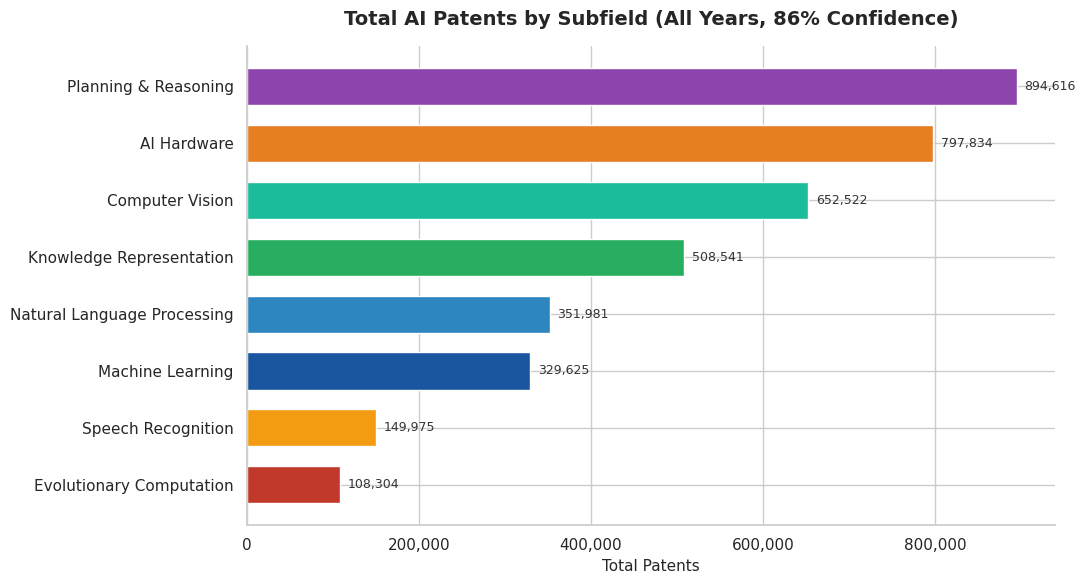

  Chart 2: Subfield totals


In [ ]:
# Chart 2 — Subfield totals (horizontal bar)
fig, ax = plt.subplots(figsize=(11, 6))
sf_sorted = df_summary.sort_values("total_patents_86", ascending=True)
colors    = [COLORS.get(sf, "#888888") for sf in sf_sorted["subfield"]]
bars      = ax.barh(sf_sorted["subfield_label"], sf_sorted["total_patents_86"], color=colors, edgecolor="white", height=0.65)
for bar in bars:
    w = bar.get_width()
    ax.text(w + max(sf_sorted["total_patents_86"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{int(w):,}", va="center", fontsize=9, color="#333")
ax.set_title("Total AI Patents by Subfield (All Years, 86% Confidence)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Total Patents", fontsize=11)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/02_subfield_totals.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 2: Subfield totals")

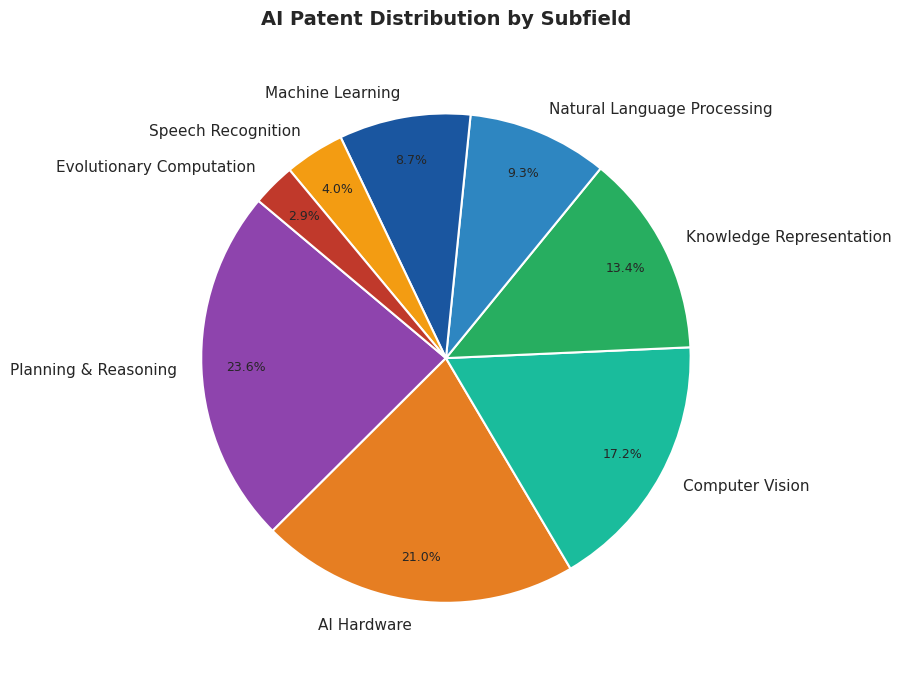

  Chart 3: Subfield share pie


In [ ]:
# Chart 3 — Subfield share pie
fig, ax = plt.subplots(figsize=(9, 9))
pie_data     = df_summary[df_summary["total_patents_86"] > 0]
wedge_colors = [COLORS.get(sf, "#aaa") for sf in pie_data["subfield"]]
wedges, texts, autotexts = ax.pie(
    pie_data["total_patents_86"],
    labels=pie_data["subfield_label"],
    autopct="%1.1f%%",
    colors=wedge_colors,
    startangle=140,
    pctdistance=0.82,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
for t in autotexts:
    t.set_fontsize(9)
ax.set_title("AI Patent Distribution by Subfield", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("charts/03_subfield_share_pie.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 3: Subfield share pie")

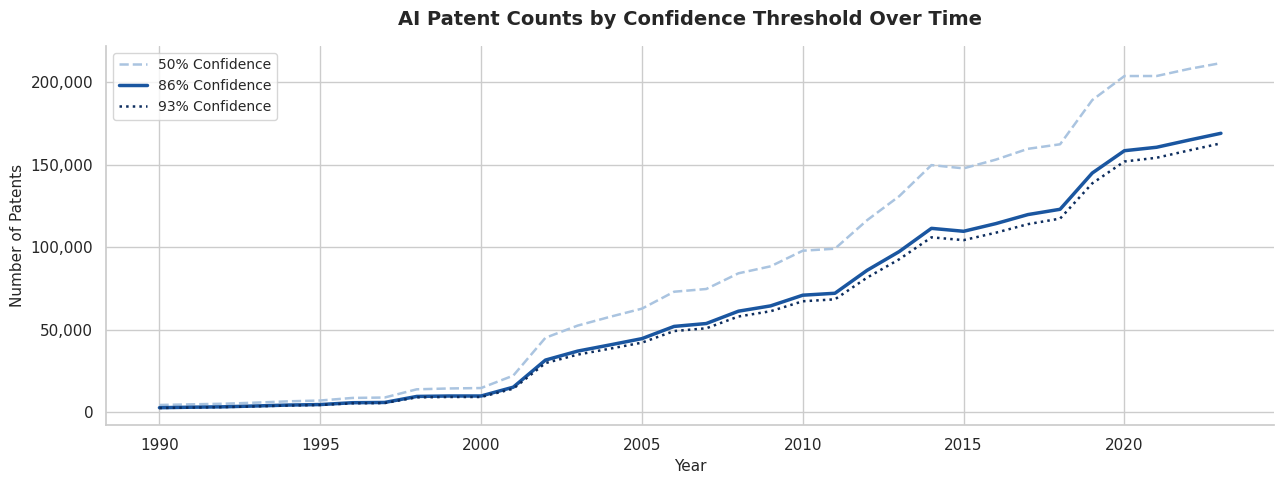

  Chart 4: Confidence tiers


In [ ]:
# Chart 4 — Confidence tiers over time
fig, ax = plt.subplots(figsize=(13, 5))
recent_tiers = df_tiers[df_tiers["year"] >= 1990]
ax.plot(recent_tiers["year"], recent_tiers["threshold_50"], label="50% Confidence", linestyle="--", color="#aac4e0", linewidth=1.8)
ax.plot(recent_tiers["year"], recent_tiers["threshold_86"], label="86% Confidence", color="#1a56a0", linewidth=2.5)
ax.plot(recent_tiers["year"], recent_tiers["threshold_93"], label="93% Confidence", linestyle=":", color="#0d2d5e", linewidth=1.8)
ax.set_title("AI Patent Counts by Confidence Threshold Over Time", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of Patents", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/04_confidence_tiers.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 4: Confidence tiers")

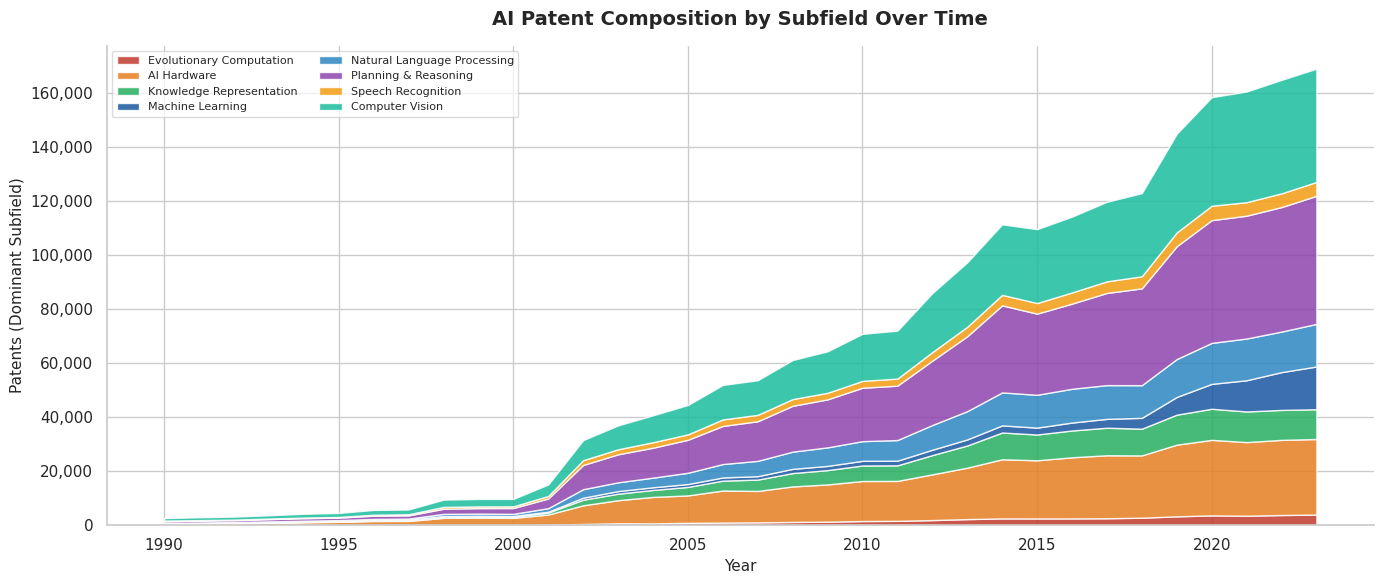

  Chart 5: Stacked area composition


In [ ]:
# Chart 5 — Stacked area: subfield composition over time
pivot = dominant_by_year[dominant_by_year["year"] >= 1990].pivot_table(
    index="year", columns="dominant_subfield", values="patents", fill_value=0
)
fig, ax = plt.subplots(figsize=(14, 6))
stack_colors = [COLORS.get(sf, "#888") for sf in pivot.columns]
ax.stackplot(pivot.index, pivot.T.values,
             labels=[SUBFIELD_LABELS.get(c, c) for c in pivot.columns],
             colors=stack_colors, alpha=0.85)
ax.set_title("AI Patent Composition by Subfield Over Time", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Patents (Dominant Subfield)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc="upper left", fontsize=8, ncol=2, framealpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/05_stacked_area_subfields.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 5: Stacked area composition")

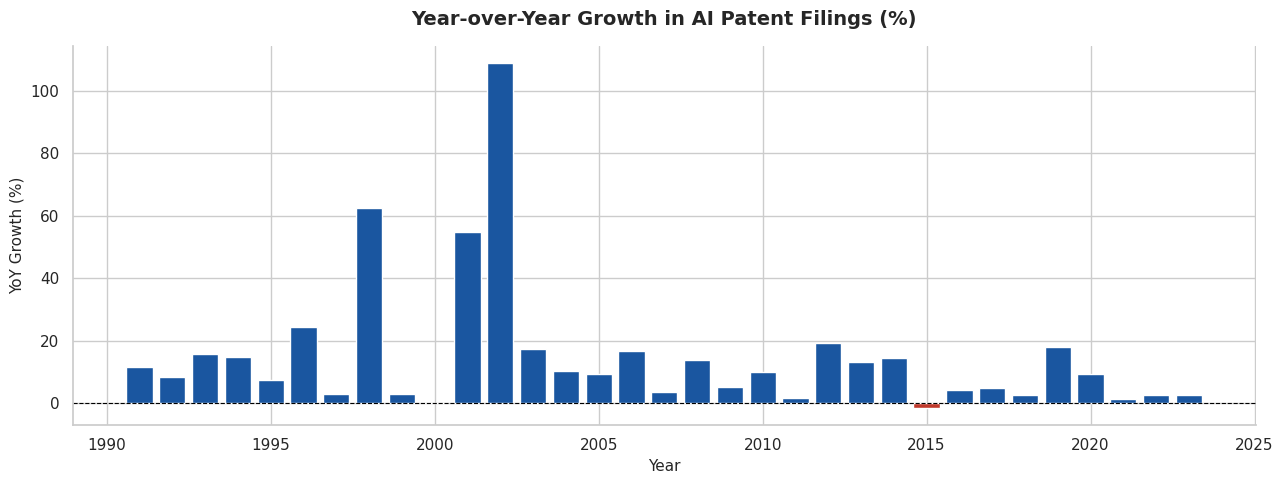

  Chart 6: YoY growth rate


In [ ]:
# Chart 6 — YoY growth rate
growth = yearly_total[(yearly_total["year"] >= 1991) & (yearly_total["year"] <= 2023)].dropna(subset=["yoy_growth"])
fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ["#c0392b" if v < 0 else "#1a56a0" for v in growth["yoy_growth"]]
ax.bar(growth["year"], growth["yoy_growth"], color=bar_colors, edgecolor="white", width=0.8)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Year-over-Year Growth in AI Patent Filings (%)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("YoY Growth (%)", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/06_yoy_growth.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 6: YoY growth rate")

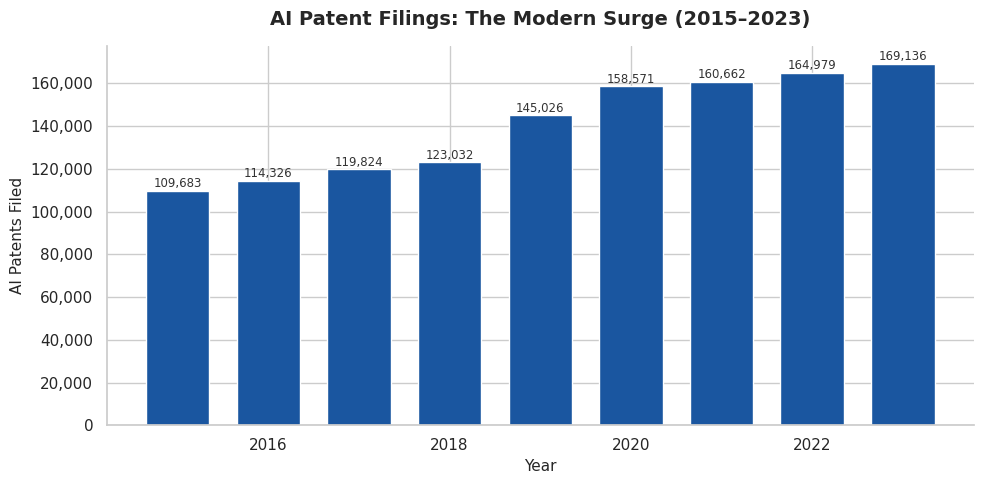

  Chart 7: Modern surge


In [ ]:
# Chart 7 — Modern surge (2015–2023)
surge = yearly_total[(yearly_total["year"] >= 2015) & (yearly_total["year"] <= 2023)]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(surge["year"], surge["ai_patents_86"], color="#1a56a0", edgecolor="white", width=0.7)
for _, row in surge.iterrows():
    ax.text(row["year"], row["ai_patents_86"] + max(surge["ai_patents_86"]) * 0.01,
            f"{int(row['ai_patents_86']):,}", ha="center", fontsize=8.5, color="#333")
ax.set_title("AI Patent Filings: The Modern Surge (2015–2023)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("AI Patents Filed", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("charts/07_modern_surge.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close()
print("  Chart 7: Modern surge")

# Key Stats

In [ ]:
total_patents = yearly_total["total_patents"].sum()
total_ai      = yearly_total["ai_patents_86"].sum()

peak_row   = yearly_total.loc[yearly_total["ai_patents_86"].idxmax()]
peak_year  = int(peak_row["year"])
peak_count = int(peak_row["ai_patents_86"])

# df_summary is sorted descending — iloc[0] is top, iloc[1] is second
top_sf    = df_summary.iloc[0]
second_sf = df_summary.iloc[1]

# CAGR 2010–2022
cagr_start = yearly_total.loc[yearly_total["year"] == 2010, "ai_patents_86"].values[0]
cagr_end   = yearly_total.loc[yearly_total["year"] == 2022, "ai_patents_86"].values[0]
cagr           = ((cagr_end / cagr_start) ** (1 / 12) - 1) * 100
growth_multiple = cagr_end / cagr_start

print(f"""
KEY STATISTICS
Total patents in dataset:   {total_patents:,}
Total AI patents (86%):     {total_ai:,}
AI share of all patents:    {total_ai/total_patents*100:.2f}%

Peak filing year:           {peak_year} ({peak_count:,} patents)

Top subfield:               {top_sf['subfield_label']} ({top_sf['share_of_ai_pct']}%)
Second subfield:            {second_sf['subfield_label']} ({second_sf['share_of_ai_pct']}%)

CAGR (2010–2022):           {cagr:.1f}% per year
Growth multiple since 2010: {growth_multiple:.1f}x
""")

stats = {
    "metric": [
        "Total patents",
        "AI patents (86%)",
        "AI share %",
        "Peak year",
        "Peak year count",
        "Top subfield",
        "Top subfield share %",
        "Second subfield",
        "Second subfield share %",
        "CAGR 2010-2022 %",
        "Growth multiple since 2010",
    ],
    "value": [
        f"{total_patents:,}",
        f"{total_ai:,}",
        f"{total_ai/total_patents*100:.2f}%",
        str(peak_year),
        f"{peak_count:,}",
        top_sf["subfield_label"],
        f"{top_sf['share_of_ai_pct']}%",
        second_sf["subfield_label"],
        f"{second_sf['share_of_ai_pct']}%",
        f"{cagr:.1f}%",
        f"{growth_multiple:.1f}x",
    ],
}

pd.DataFrame(stats).to_csv(f"{OUTPUT_DIR}/00_key_stats.csv", index=False)
print("All outputs saved.")


KEY STATISTICS
Total patents in dataset:   15,437,542
Total AI patents (86%):     2,182,808
AI share of all patents:    14.14%

Peak filing year:           2023 (169,136 patents)

Top subfield:               Planning & Reasoning (23.58%)
Second subfield:            AI Hardware (21.03%)

CAGR (2010–2022):           7.3% per year
Growth multiple since 2010: 2.3x

All outputs saved.
